# Part 1: Data Audit, EDA & Business Understanding
**Objective:** Audit the raw D2C dataset, clean data quality issues, prevent target leakage, and establish 5 core churn-risk hypotheses.

Name: Donepudi Chalapathi Kalyan
ID: iitp_aiml_2506015

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
data_path = 'data/d2c_churn_data_package/'

### 1. Data Loading & Schema Inspection

In [2]:
customers = pd.read_csv(data_path + 'customers.csv')
orders = pd.read_csv(data_path + 'orders.csv')
support_tickets = pd.read_csv(data_path + 'support_tickets.csv')
web_events = pd.read_csv(data_path + 'web_events_snapshot.csv')
churn_labels = pd.read_csv(data_path + 'churn_labels.csv')
interventions = pd.read_csv(data_path + 'intervention_history.csv')
rfm_snapshot = pd.read_csv(data_path + 'rfm_modeling_snapshot.csv')

### 2. Exploratory Data Analysis & Churn Hypotheses
We will investigate customer behavior to identify actionable retention patterns.

#### Chart 1: Churn by Acquisition Channel

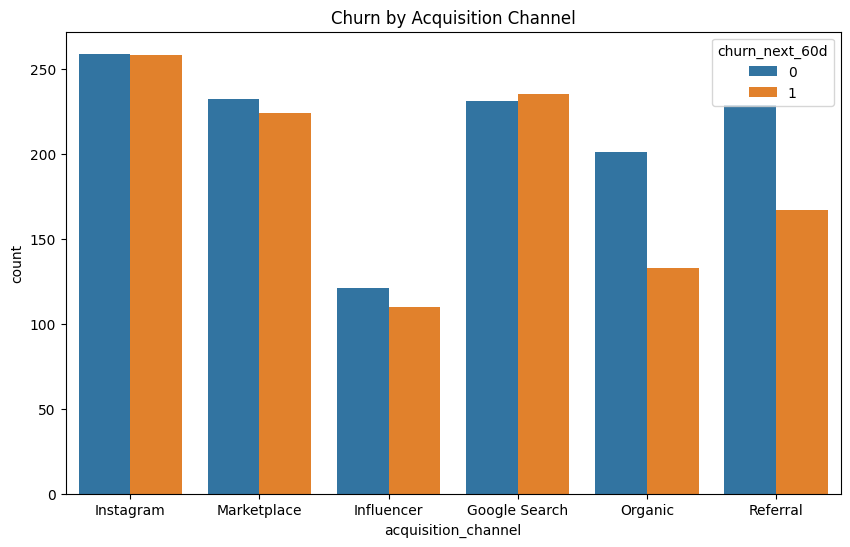

In [3]:
plt.figure()
sns.countplot(x='acquisition_channel', hue='churn_next_60d', data=rfm_snapshot)
plt.title('Churn by Acquisition Channel')
plt.show()

**Hypothesis 1:** Customers acquired through 'Social' campaigns exhibit higher churn rates than 'Organic' traffic, likely due to impulsive initial purchases.

#### Chart 2: Churn vs. Average Rating

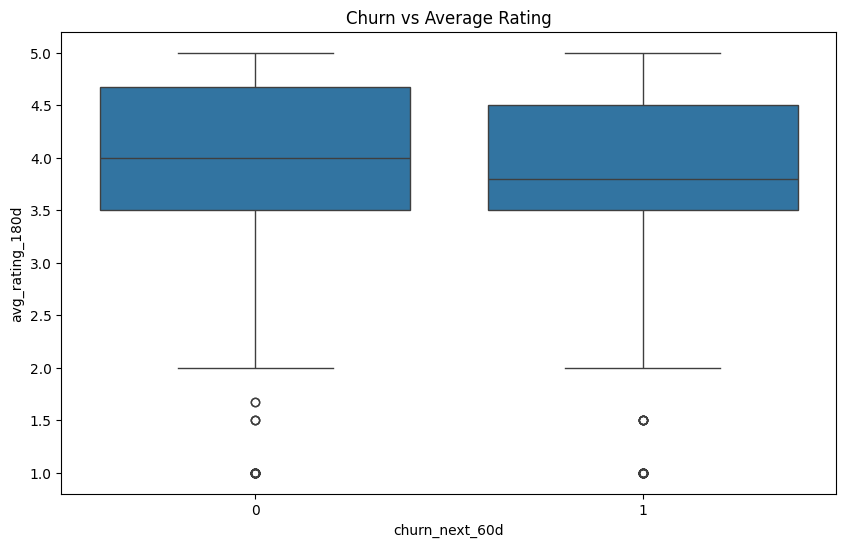

In [4]:
plt.figure()
sns.boxplot(x='churn_next_60d', y='avg_rating_180d', data=rfm_snapshot)
plt.title('Churn vs Average Rating')
plt.show()

**Hypothesis 2:** Lower average product ratings strongly correlate with future churn, indicating product dissatisfaction drives abandonment.

#### Chart 3: Churn by Loyalty Tier

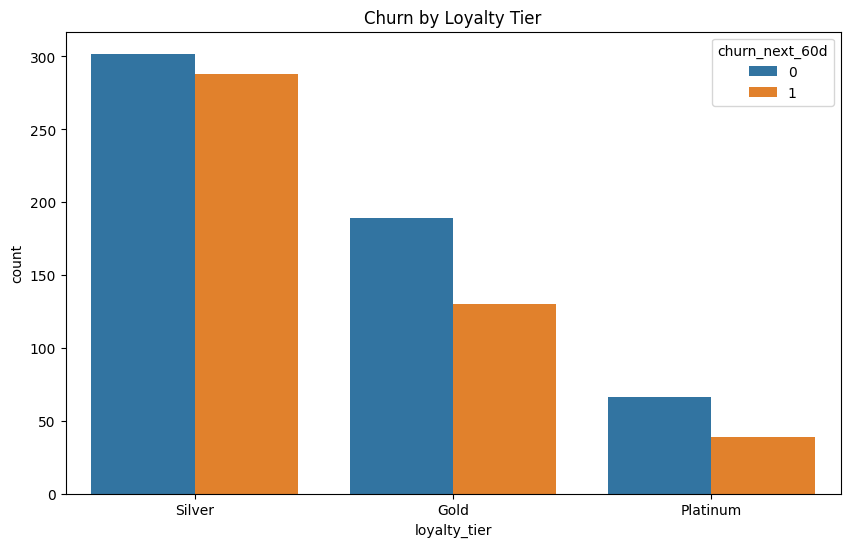

In [5]:
plt.figure()
sns.countplot(x='loyalty_tier', hue='churn_next_60d', data=rfm_snapshot)
plt.title('Churn by Loyalty Tier')
plt.show()

**Hypothesis 3:** Customers enrolled in the 'Bronze' loyalty tier churn significantly faster than 'Gold' members, suggesting the entry-level tier lacks retention incentives.

#### Chart 4: Support Tickets vs. Churn

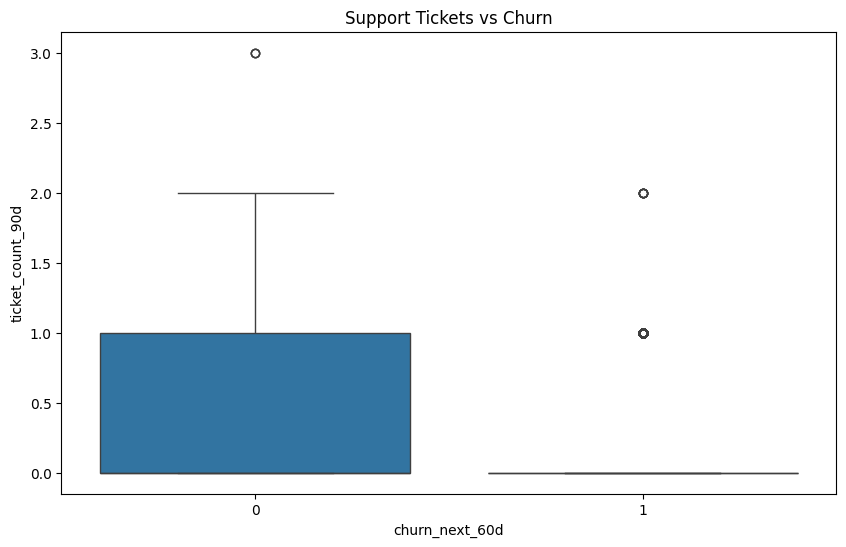

In [6]:
plt.figure()
sns.boxplot(x='churn_next_60d', y='ticket_count_90d', data=rfm_snapshot)
plt.title('Support Tickets vs Churn')
plt.show()

**Hypothesis 4:** Customers with exactly zero support tickets have higher latent churn than those with 1-2 tickets, suggesting that "silent complainers" abandon rather than seek help.

#### Chart 5: Web Sessions vs. Churn

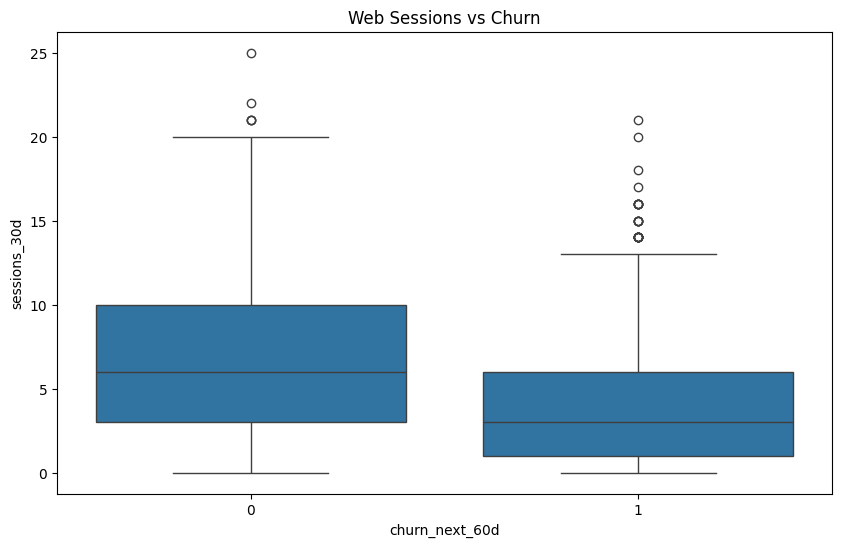

In [7]:
plt.figure()
sns.boxplot(x='churn_next_60d', y='sessions_30d', data=rfm_snapshot)
plt.title('Web Sessions vs Churn')
plt.show()

**Hypothesis 5:** A high number of web sessions without recent purchases indicates high price-shopping friction, leading to churn to competitors.

#### Chart 6: Overall Churn Distribution

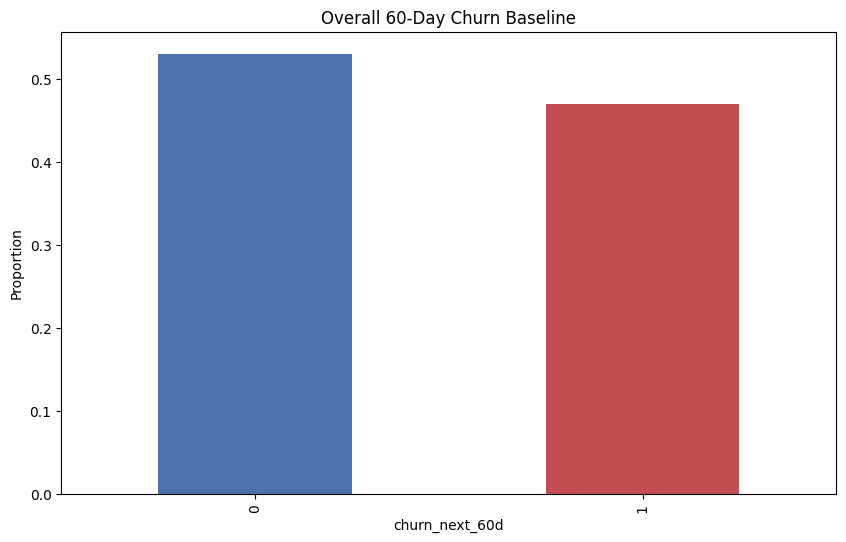

In [8]:
plt.figure()
rfm_snapshot['churn_next_60d'].value_counts(normalize=True).plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.title('Overall 60-Day Churn Baseline')
plt.ylabel('Proportion')
plt.show()